# MODUL PRAKTIKUM BIG DATA
## Pertemuan 2 — Instalasi Lingkungan Kerja (Anaconda, Jupyter)

| | |
|---|---|
| **Mata Kuliah** | Praktikum Big Data |
| **Program Studi** | Teknologi Informasi — Universitas Tidar |
| **Pertemuan** | 2 |
| **Topik Pertemuan 2** | Instalasi Python Environment (Anaconda) & Pengenalan Jupyter Notebook |
| **Waktu** | 3 x 50 menit |

---


# PERTEMUAN 2 — Instalasi Python Environment (Anaconda) & Pengenalan Jupyter Notebook

## Tujuan Pembelajaran

Setelah menyelesaikan Pertemuan 2, mahasiswa mampu:
1. Menggunakan perintah dasar terminal Linux untuk navigasi dan manajemen berkas.
2. Memasang Anaconda di Ubuntu sebagai platform pengelola Python dan pustaka data science.
3. Membuat *conda environment* terisolasi khusus untuk praktikum Big Data.
4. Menjalankan Jupyter Notebook dan memahami antarmuka dasarnya.
5. Menulis dan menjalankan kode Python dasar untuk eksplorasi data menggunakan pandas, numpy, dan matplotlib.

---

## 2.1 Pengenalan Dasar Terminal Linux

Sebelum memasang Anaconda, kita perlu pelajari beberapa perintah dasar terminal Ubuntu yang akan sering digunakan sepanjang praktikum ini. Buka **Terminal**, lalu coba jalankan perintah-perintah berikut satu per satu:

| Perintah | Fungsi |
|---|---|
| `pwd` | Menampilkan direktori (folder) tempat kita berada saat ini |
| `ls` | Menampilkan daftar isi folder |
| `ls -la` | Menampilkan daftar isi folder secara detail, termasuk file tersembunyi |
| `cd nama_folder` | Berpindah ke dalam folder tertentu |
| `cd ..` | Berpindah ke folder satu tingkat di atasnya |
| `cd ~` | Kembali ke folder utama (*home directory*) |
| `mkdir nama_folder` | Membuat folder baru |
| `sudo perintah` | Menjalankan perintah dengan hak akses administrator (*superuser*) |

**Latihan singkat:** Buat folder khusus untuk menyimpan seluruh berkas praktikum semester ini:

```bash
cd ~
mkdir praktikum-bigdata
cd praktikum-bigdata
pwd
```

Perintah terakhir (`pwd`) seharusnya menampilkan sesuatu seperti `/home/mahasiswa/praktikum-bigdata` — folder inilah yang akan kita gunakan sepanjang semester untuk menyimpan modul dan tugas.

---

## 2.2 Instalasi Anaconda di Ubuntu

**Anaconda** adalah distribusi Python yang sudah dilengkapi dengan ribuan pustaka data science (termasuk pandas, numpy, matplotlib, dan Jupyter) sekaligus **conda** — pengelola paket dan environment yang akan menjaga agar versi-versi pustaka yang kita pasang senantiasa kompatibel satu sama lain.

Kita akan memasang **Anaconda versi terbaru untuk Linux (64-bit)**.

**Langkah-langkah:**

1. Di dalam VM Ubuntu, buka **Firefox**, kunjungi **https://www.anaconda.com/download**
2. Pilih paket untuk **Linux**, lalu unduh installer (berformat `.sh`, contoh nama file: `Anaconda3-2025.12-Linux-x86_64.sh`). Biasanya tersimpan otomatis di folder `~/Downloads`.
3. Buka **Terminal**, arahkan ke folder unduhan:

```bash
cd ~/Downloads
ls
```

Pastikan file `Anaconda3-*.sh` terlihat pada daftar.

4. Jalankan installer:

```bash
bash Anaconda3-*-Linux-x86_64.sh
```

5. Ikuti proses instalasi di terminal:
   - Tekan **Enter** untuk membaca lisensi, lalu tekan **spasi berulang kali** hingga sampai di akhir teks lisensi
   - Ketik `yes` lalu **Enter** untuk menyetujui lisensi
   - Tekan **Enter** untuk menyetujui lokasi instalasi default (`/home/mahasiswa/anaconda3`)
   - Tunggu proses instalasi paket berjalan (memakan waktu beberapa menit)
   - Ketik `yes` lalu **Enter** ketika ditanya *"Do you wish to update your shell profile to automatically initialize conda?"*
6. Setelah selesai, **tutup dan buka kembali Terminal** (atau jalankan `source ~/.bashrc`) agar perintah `conda` dapat dikenali.
7. Verifikasi instalasi berhasil:

```bash
conda --version
```

Output yang diharapkan (angka versi persis dapat sedikit berbeda, yang penting perintah dikenali tanpa error):

```
conda 25.11.1
```

> **Highlight** Perhatikan bahwa setelah instalasi, di depan baris terminal anda akan muncul tulisan `(base)` — ini menandakan anda sedang berada di *base environment* bawaan Anaconda. Pada langkah berikutnya, akan dibuat environment baru **khusus** untuk praktikum ini agar tidak tercampur antara library untuk praktikum ini dengan library bawaan sistem.

---

## 2.3 Membuat Conda Environment untuk Big Data


Kita akan membuat environment bernama **`bigdata`** dengan kombinasi versi berikut — kombinasi ini **sudah teruji saling kompatibel** dan juga mendukung PySpark yang akan digunakan pada pertemuan-pertemuan mendatang:

| Komponen | Versi |
|---|---|
| Python | **3.11** |
| pandas | **2.2.x** |
| numpy | **1.26.x** |
| matplotlib | **3.8.x** |
| jupyter / notebook | **versi terbaru (7.x)** |

**Jalankan perintah berikut di Terminal:**

```bash
conda create -n bigdata python=3.11 pandas=2.2 numpy=1.26 matplotlib=3.8 jupyter notebook seaborn -c conda-forge -y
```

Perintah ini akan melakukan download dan install seluruh package di atas sekaligus dalam satu environment bernama `bigdata`. Proses ini dapat memakan waktu 5–15 menit tergantung koneksi internet — conda akan menampilkan daftar paket yang akan di install sebelum anda download.

Setelah proses selesai, **aktifkan** environment yang baru dibuat:

```bash
conda activate bigdata
```

Perhatikan tulisan `(base)` di terminal kalian akan berubah menjadi **`(bigdata)`** — ini menandakan anda sekarang bekerja di dalam environment `bigdata`, bukan lagi di `base`.

Verifikasi seluruh versi paket terpasang dengan benar:

```bash
python --version
python -c "import pandas, numpy, matplotlib; print('pandas', pandas.__version__); print('numpy', numpy.__version__); print('matplotlib', matplotlib.__version__)"
```

Output yang diharapkan kurang lebih:

```
Python 3.11.x
pandas 2.2.x
numpy 1.26.x
matplotlib 3.8.x
```

> **Highlight:** Mulai sekarang, **setiap kali membuka Terminal baru** untuk praktikum Big Data, selalu jalankan `conda activate bigdata` terlebih dahulu sebelum menjalankan Python atau Jupyter. Jika lupa, anda akan bekerja di environment `base` yang versi library nya bisa berbeda.

---

## 2.4 Menjalankan Jupyter Notebook

**Langkah-langkah:**

1. Pastikan environment `bigdata` sedang aktif (terminal menampilkan `(bigdata)`). Jika belum:

```bash
conda activate bigdata
```

2. Arahkan ke folder praktikum yang telah dibuat sebelumnya:

```bash
cd ~/praktikum-bigdata
```

3. Salin (atau pindahkan) file modul `.ipynb` ini ke dalam folder tersebut, misalnya menggunakan file manager Ubuntu (drag-and-drop dari folder Downloads), atau dapat pula memindahkannya lewat terminal jika sudah tahu lokasinya:

```bash
mv ~/Downloads/Modul_Praktikum_BigData_Pertemuan2.ipynb ~/praktikum-bigdata/
```

4. Jalankan Jupyter Notebook:

```bash
jupyter notebook
```

5. Browser akan otomatis terbuka menampilkan antarmuka **Jupyter Notebook** dengan daftar isi folder `praktikum-bigdata`. Jika browser tidak terbuka otomatis, salin URL yang muncul di terminal (formatnya seperti `http://localhost:8888/tree?token=...`) dan tempel ke browser secara manual.
6. Klik file **`Modul_Praktikum_BigData_Pertemuan2.ipynb`** pada daftar untuk membukanya di dalam Jupyter.



In [1]:
# Coba Run ini
print("Hello World!")
print("Environment berjalan dengan baik")

Hello World!
Environment berjalan dengan baik


---

## 2.5 Hands-On: Python Dasar untuk Eksplorasi Data

Mulai dari sini, kita akan berlatih menggunakan tiga library utama yang akan menjadi tulang punggung praktikum sepanjang semester:
- **pandas** — untuk mengelola dan menganalisis data berbentuk tabel
- **numpy** — untuk operasi numerik/matematis yang efisien
- **matplotlib** — untuk membuat visualisasi data sederhana

### 2.5.1 Verifikasi Versi Library

Sebelum mulai, selalu merupakan kebiasaan baik untuk memeriksa versi library yang sedang kita gunakan — ini akan sangat membantu ketika suatu saat anda mengalami error

In [3]:
# Cek versi library
import sys
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

print("Python      :", sys.version.split()[0])
print("pandas      :", pd.__version__)
print("numpy       :", np.__version__)
print("matplotlib  :", matplotlib.__version__)

Python      : 3.11.16
pandas      : 2.2.3
numpy       : 1.26.4
matplotlib  : 3.8.4


### 2.5.2 Variabel dan Tipe Data Dasar di Python


In [4]:
# Tipe data dasar di Python
nama_mahasiswa = "Budi"         # string (teks)
npm = 210411001                 # integer (bilangan bulat)
ipk = 3.75                      # float (bilangan desimal)
aktif_kuliah = True             # boolean (benar/salah)

print(f"Nama       : {nama_mahasiswa} ({type(nama_mahasiswa).__name__})")
print(f"NPM        : {npm} ({type(npm).__name__})")
print(f"IPK        : {ipk} ({type(ipk).__name__})")
print(f"Aktif      : {aktif_kuliah} ({type(aktif_kuliah).__name__})")

Nama       : Budi (str)
NPM        : 210411001 (int)
IPK        : 3.75 (float)
Aktif      : True (bool)


In [5]:

daftar_nilai = [85, 90, 78, 92, 88]   # list: kumpulan nilai terurut
print("Daftar nilai:", daftar_nilai)
print("Rata-rata   :", sum(daftar_nilai) / len(daftar_nilai))

mahasiswa = {                          # dictionary: pasangan key-value
    "nama": "Budi",
    "npm": 210411001,
    "jurusan": "Teknologi Informasi",
    "semester": 3
}
print("\nData mahasiswa:")
for key, value in mahasiswa.items():
    print(f"  {key}: {value}")

Daftar nilai: [85, 90, 78, 92, 88]
Rata-rata   : 86.6

Data mahasiswa:
  nama: Budi
  npm: 210411001
  jurusan: Teknologi Informasi
  semester: 3


### 2.5.3 Membuat dan Mengeksplorasi DataFrame dengan pandas

**DataFrame** adalah struktur data utama pandas — bentuknya seperti tabel Excel, dengan baris dan kolom. Kita akan membuat contoh data penjualan produk UMKM sederhana untuk berlatih.

In [6]:
# Membuat DataFrame dari dictionary
# Studi kasus: data penjualan mingguan sebuah UMKM di beberapa kota

data_penjualan = {
    "kota": ["Magelang", "Yogyakarta", "Semarang", "Solo", "Magelang", "Yogyakarta", "Semarang", "Solo"],
    "minggu": [1, 1, 1, 1, 2, 2, 2, 2],
    "produk": ["Kaos", "Kaos", "Kaos", "Kaos", "Kaos", "Kaos", "Kaos", "Kaos"],
    "unit_terjual": [120, 95, 150, 80, 135, 110, 160, 90],
    "harga_satuan": [75000, 75000, 75000, 75000, 75000, 75000, 75000, 75000]
}

df = pd.DataFrame(data_penjualan)
df

,kota,minggu,produk,unit_terjual,harga_satuan
0,Magelang,1,Kaos,120,75000
1,Yogyakarta,1,Kaos,95,75000
2,Semarang,1,Kaos,150,75000
3,Solo,1,Kaos,80,75000
4,Magelang,2,Kaos,135,75000
5,Yogyakarta,2,Kaos,110,75000
6,Semarang,2,Kaos,160,75000
7,Solo,2,Kaos,90,75000


Beberapa fungsi dasar pandas yang paling sering digunakan untuk mengenal data baru:

In [7]:
# Melihat 5 baris pertama
df.head()

,kota,minggu,produk,unit_terjual,harga_satuan
0,Magelang,1,Kaos,120,75000
1,Yogyakarta,1,Kaos,95,75000
2,Semarang,1,Kaos,150,75000
3,Solo,1,Kaos,80,75000
4,Magelang,2,Kaos,135,75000


In [8]:
# Informasi struktur data: jumlah baris, tipe data tiap kolom, dan memori yang digunakan
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   kota          8 non-null      object
 1   minggu        8 non-null      int64 
 2   produk        8 non-null      object
 3   unit_terjual  8 non-null      int64 
 4   harga_satuan  8 non-null      int64 
dtypes: int64(3), object(2)
memory usage: 452.0+ bytes


In [9]:
# Ringkasan statistik deskriptif untuk kolom numerik
df.describe()

,minggu,unit_terjual,harga_satuan
count,8.000000,8.000000,8.0
mean,1.500000,117.500000,75000.0
std,0.534522,29.032002,0.0
min,1.000000,80.000000,75000.0
25%,1.000000,93.750000,75000.0
50%,1.500000,115.000000,75000.0
75%,2.000000,138.750000,75000.0
max,2.000000,160.000000,75000.0


In [10]:
# Menambahkan kolom baru hasil perhitungan: total pendapatan = unit_terjual x harga_satuan
df["total_pendapatan"] = df["unit_terjual"] * df["harga_satuan"]
df

,kota,minggu,produk,unit_terjual,harga_satuan,total_pendapatan
0,Magelang,1,Kaos,120,75000,9000000
1,Yogyakarta,1,Kaos,95,75000,7125000
2,Semarang,1,Kaos,150,75000,11250000
3,Solo,1,Kaos,80,75000,6000000
4,Magelang,2,Kaos,135,75000,10125000
5,Yogyakarta,2,Kaos,110,75000,8250000
6,Semarang,2,Kaos,160,75000,12000000
7,Solo,2,Kaos,90,75000,6750000


### 2.5.4 Operasi Dasar: Filtering dan Pengelompokan Data

Dua operasi yang paling sering dilakukan saat eksplorasi data: **menyaring (filter)** baris tertentu, dan **mengelompokkan (group by)** data untuk melihat ringkasan per kategori.

In [11]:
# Filtering: menampilkan hanya data dari kota Magelang
data_magelang = df[df["kota"] == "Magelang"]
data_magelang

,kota,minggu,produk,unit_terjual,harga_satuan,total_pendapatan
0,Magelang,1,Kaos,120,75000,9000000
4,Magelang,2,Kaos,135,75000,10125000


In [12]:
# Filtering dengan lebih dari satu kondisi:
# tampilkan data dengan unit_terjual lebih dari 100 DAN minggu ke-2
data_filter = df[(df["unit_terjual"] > 100) & (df["minggu"] == 2)]
data_filter

,kota,minggu,produk,unit_terjual,harga_satuan,total_pendapatan
4,Magelang,2,Kaos,135,75000,10125000
5,Yogyakarta,2,Kaos,110,75000,8250000
6,Semarang,2,Kaos,160,75000,12000000


In [13]:
# Group by: total pendapatan per kota (menjumlahkan data minggu 1 dan minggu 2)
total_per_kota = df.groupby("kota")["total_pendapatan"].sum().sort_values(ascending=False)
print("Total pendapatan per kota (2 minggu):")
total_per_kota

Total pendapatan per kota (2 minggu):


kota
Semarang      23250000
Magelang      19125000
Yogyakarta    15375000
Solo          12750000
Name: total_pendapatan, dtype: int64

---

## 📝 Latihan Mandiri

**Soal 1.** Buatlah sebuah DataFrame baru bernama `df_nilai` yang berisi data nilai 5 mahasiswa (kolom: `nama`, `uts`, `uas`). Tambahkan kolom baru `nilai_akhir` yang dihitung dari `(uts * 0.4) + (uas * 0.6)`.

In [19]:
import pandas as pd

daftar_nilai = {
    "nama" : ["irkham", "adnan", "raka", "hanif", "dimas"],
    "uts" : [95,90,85,80,75],
    "uas" : [100,95,90,85,80],
}
df_nilai = pd.DataFrame(daftar_nilai)
df_nilai["nilai_akhir"] = (df_nilai["uts"] * 0.4) + (df_nilai["uas"] * 0.6)

print("Daftar nilai mahasiswa")
df_nilai


Daftar nilai mahasiswa


,nama,uts,uas,nilai_akhir
0,irkham,95,100,98.0
1,adnan,90,95,93.0
2,raka,85,90,88.0
3,hanif,80,85,83.0
4,dimas,75,80,78.0


**Soal 2.** Dari DataFrame `df_nilai` yang telah dibuat, tampilkan hanya mahasiswa dengan `nilai_akhir` di atas 80.

In [16]:
nilai_akhir_di_atas_80 = df_nilai[df_nilai["nilai_akhir"] > 80]

print("Daftar mahasiswa dengan nilai di atas 80")
nilai_akhir_di_atas_80


Daftar mahasiswa dengan nilai di atas 80


,nama,uts,uas,nilai_akhir
0,irkham,95,100,98.0
1,adnan,90,95,93.0
2,raka,85,90,88.0
3,hanif,80,85,83.0


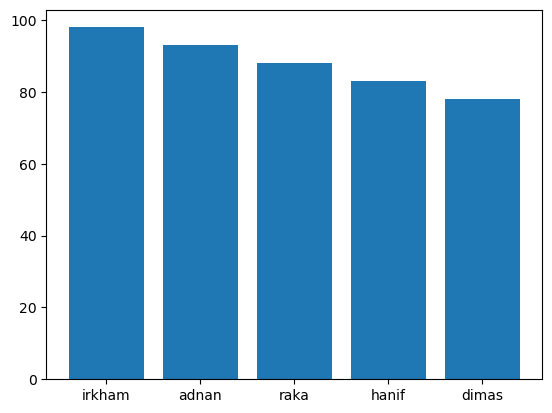

In [25]:
import matplotlib.pyplot as plt

plt.bar(df_nilai['nama'], df_nilai['nilai_akhir'])
plt.show()

In [24]:
import numpy as np

nilai_array = np.array(df_nilai['nilai_akhir'])
print("Nilai rata-rata : ", np.mean(nilai_array))

Nilai rata-rata :  88.0
